# Suicide Rates EDA (1985–2016)
Replicating the key analyses taken from [lmorgan95's R notebook](https://www.kaggle.com/code/lmorgan95/r-suicide-rates-in-depth-stats-insights/report) — translated to Python.

**Sections:**
1. Setup & Data Overview
2. Global Trend Over Time
3. By Sex
4. By Age Group
5. By Generation
6. Top & Bottom Countries
7. GDP vs Suicide Rate

## 1. Setup & Data Overview

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
})
PALETTE = sns.color_palette('Set2')
SEX_COLORS = {'male': '#4C72B0', 'female': '#DD8452'}

AGE_ORDER = ['5-14 years', '15-24 years', '25-34 years',
             '35-54 years', '55-74 years', '75+ years']
GEN_ORDER  = ['G.I. Generation', 'Silent', 'Boomers',
              'Generation X', 'Millenials', 'Generation Z']

In [4]:
df = pd.read_csv("C:\\Users\\Lukasz\\Downloads\\master.csv")

# ── Clean column names ─────────────────────────────────────────────────────
df.columns = df.columns.str.strip()
df = df.rename(columns={
    'suicides/100k pop': 'suicides_per_100k',
    'HDI for year':      'hdi',
    'gdp_for_year ($)':  'gdp_total',
    'gdp_per_capita ($)':'gdp_per_capita',
    'country-year':      'country_year',
})

# ── Tidy types ─────────────────────────────────────────────────────────────
df['gdp_total'] = df['gdp_total'].str.replace(',', '').astype(float)
df['age']       = pd.Categorical(df['age'],       categories=AGE_ORDER,  ordered=True)
df['generation']= pd.Categorical(df['generation'],categories=GEN_ORDER,  ordered=True)

print(f"Shape : {df.shape}")
print(f"Years : {df['year'].min()} – {df['year'].max()}")
print(f"Countries: {df['country'].nunique()}")
df.head()

Shape : (27820, 12)
Years : 1985 – 2016
Countries: 101


,country,year,sex,age,suicides_no,population,suicides_per_100k,country_year,hdi,gdp_total,gdp_per_capita,generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,2.156625e+09,796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,2.156625e+09,796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,2.156625e+09,796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,2.156625e+09,796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,2.156625e+09,796,Boomers


In [5]:
# ── Missing values ─────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing[missing > 0]

hdi    19456
dtype: int64

In [6]:
# ── Basic descriptive stats ────────────────────────────────────────────────
df[['suicides_no', 'population', 'suicides_per_100k', 'gdp_per_capita']].describe().round(2)

,suicides_no,population,suicides_per_100k,gdp_per_capita
count,27820.00,27820.00,27820.00,27820.00
mean,242.57,1844793.62,12.82,16866.46
std,902.05,3911779.44,18.96,18887.58
min,0.00,278.00,0.00,251.00
25%,3.00,97498.50,0.92,3447.00
50%,25.00,430150.00,5.99,9372.00
75%,131.00,1486143.25,16.62,24874.00
max,22338.00,43805214.00,224.97,126352.00


## 2. Global Trend Over Time
Aggregate suicides per 100k population for each year across all countries.

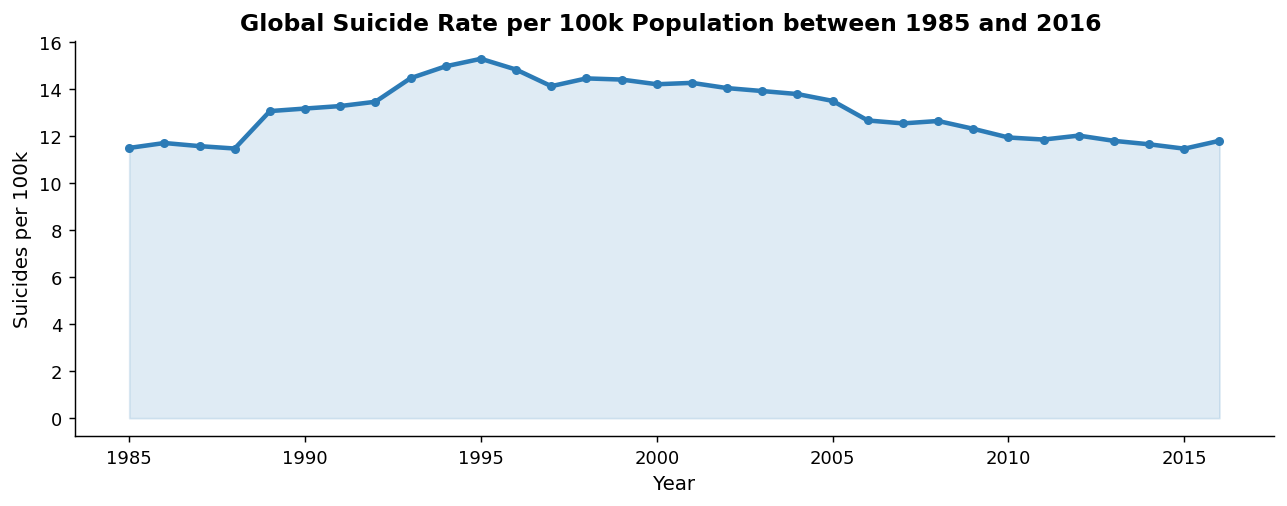

In [8]:
global_year = (
    df.groupby('year')
      .agg(suicides=('suicides_no', 'sum'),
           population=('population', 'sum'))
      .assign(rate=lambda x: x['suicides'] / x['population'] * 100_000)
      .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(global_year['year'], global_year['rate'],
        color='#2c7bb6', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(global_year['year'], global_year['rate'],
                alpha=0.15, color='#2c7bb6')
ax.set(title='Global Suicide Rate per 100k Population between 1985 and 2016 ',
       xlabel='Year', ylabel='Suicides per 100k')
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
plt.tight_layout()
plt.show()

## 3. By Sex
Compare male vs female suicide rates across every year.

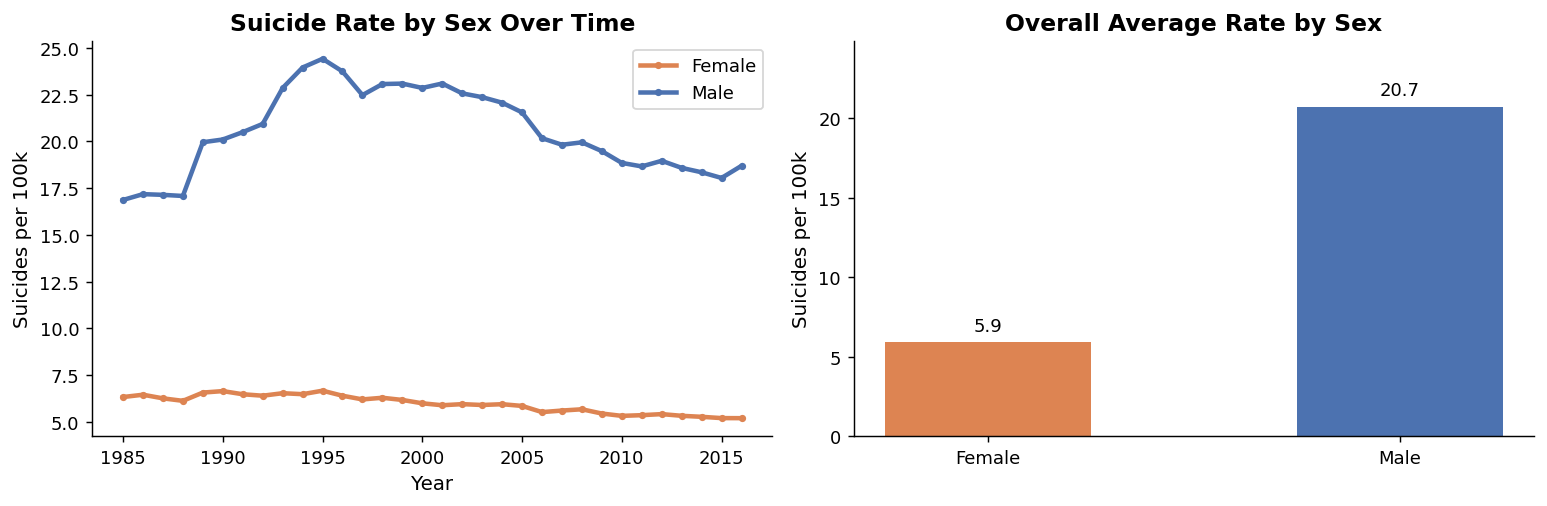

Male-to-female ratio: 3.5×


In [10]:
sex_year = (
    df.groupby(['year', 'sex'])
      .agg(suicides=('suicides_no', 'sum'),
           population=('population', 'sum'))
      .assign(rate=lambda x: x['suicides'] / x['population'] * 100_000)
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Line chart ─────────────────────────────────────────────────────────────
for sex, grp in sex_year.groupby('sex'):
    axes[0].plot(grp['year'], grp['rate'],
                 label=sex.capitalize(), color=SEX_COLORS[sex],
                 linewidth=2.5, marker='o', markersize=3)
axes[0].set(title='Suicide Rate by Sex Over Time',
            xlabel='Year', ylabel='Suicides per 100k')
axes[0].legend()

# ── Overall bar ────────────────────────────────────────────────────────────
sex_total = (
    df.groupby('sex')
      .agg(suicides=('suicides_no', 'sum'),
           population=('population', 'sum'))
      .assign(rate=lambda x: x['suicides'] / x['population'] * 100_000)
      .reset_index()
)
bars = axes[1].bar(sex_total['sex'].str.capitalize(),
                   sex_total['rate'],
                   color=[SEX_COLORS[s] for s in sex_total['sex']], width=0.5)
axes[1].bar_label(bars, fmt='%.1f', padding=4, fontsize=10)
axes[1].set(title='Overall Average Rate by Sex',
            ylabel='Suicides per 100k', ylim=(0, sex_total['rate'].max()*1.2))

plt.tight_layout()
plt.show()

ratio = sex_total.set_index('sex')['rate']
print(f"Male-to-female ratio: {ratio['male']/ratio['female']:.1f}×")

## 4. By Age Group

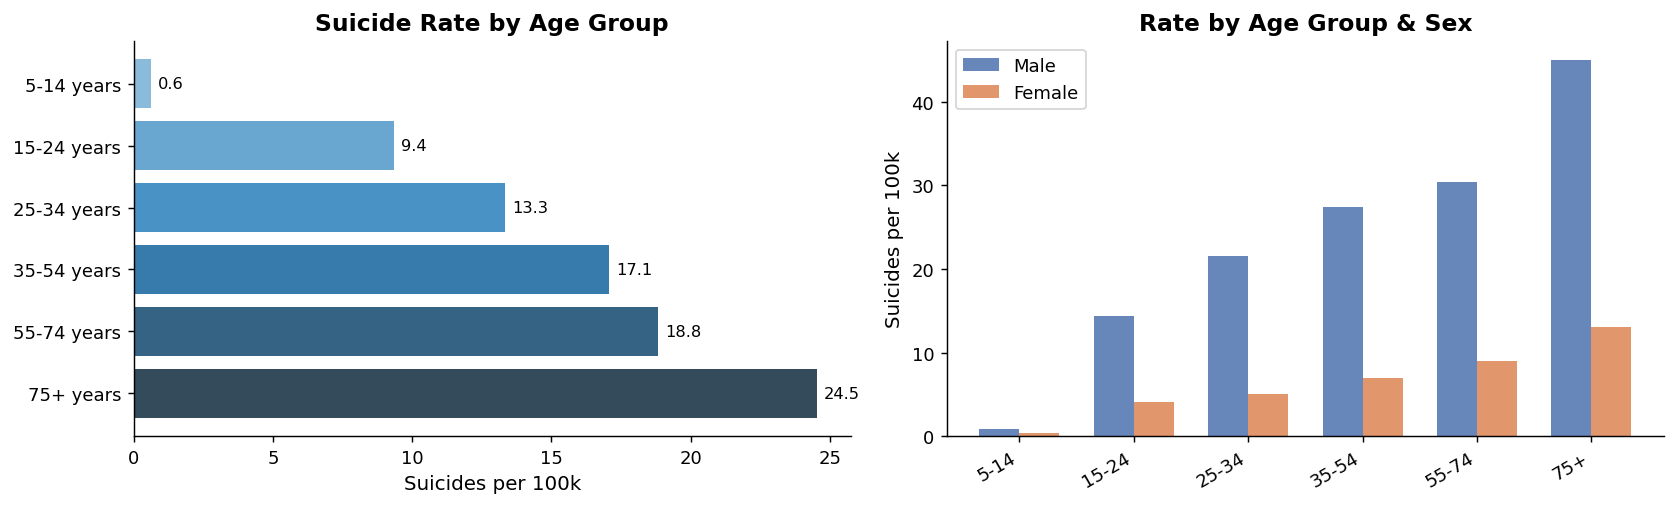

In [12]:
age_total = (
    df.groupby('age')
      .agg(suicides=('suicides_no', 'sum'),
           population=('population', 'sum'))
      .assign(rate=lambda x: x['suicides'] / x['population'] * 100_000)
      .reset_index()
      .sort_values('age')
)

age_sex = (
    df.groupby(['age', 'sex'])
      .agg(suicides=('suicides_no', 'sum'),
           population=('population', 'sum'))
      .assign(rate=lambda x: x['suicides'] / x['population'] * 100_000)
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Overall by age ─────────────────────────────────────────────────────────
colors = sns.color_palette('Blues_d', len(AGE_ORDER))
bars = axes[0].barh(age_total['age'].astype(str), age_total['rate'],
                    color=colors)
axes[0].bar_label(bars, fmt='%.1f', padding=4, fontsize=9)
axes[0].set(title='Suicide Rate by Age Group',
            xlabel='Suicides per 100k')
axes[0].invert_yaxis()

# ── Age × Sex grouped bar ──────────────────────────────────────────────────
age_pivot = age_sex.pivot(index='age', columns='sex', values='rate').sort_index()
x = np.arange(len(AGE_ORDER))
w = 0.35
axes[1].bar(x - w/2, age_pivot['male'],   width=w, label='Male',
            color=SEX_COLORS['male'],   alpha=0.85)
axes[1].bar(x + w/2, age_pivot['female'], width=w, label='Female',
            color=SEX_COLORS['female'], alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels([a.replace(' years','') for a in AGE_ORDER], rotation=30, ha='right')
axes[1].set(title='Rate by Age Group & Sex', ylabel='Suicides per 100k')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. By Generation

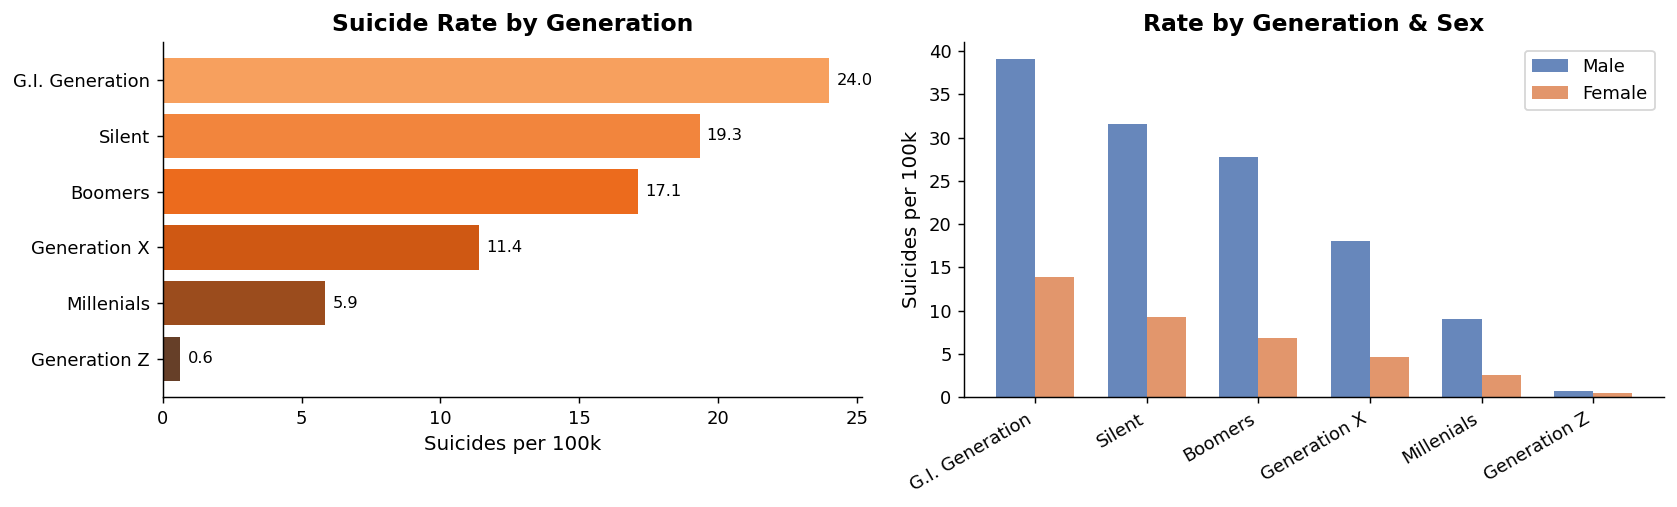

In [14]:
gen_total = (
    df.groupby('generation')
      .agg(suicides=('suicides_no', 'sum'),
           population=('population', 'sum'))
      .assign(rate=lambda x: x['suicides'] / x['population'] * 100_000)
      .reset_index()
      .sort_values('generation')
)

gen_sex = (
    df.groupby(['generation', 'sex'])
      .agg(suicides=('suicides_no', 'sum'),
           population=('population', 'sum'))
      .assign(rate=lambda x: x['suicides'] / x['population'] * 100_000)
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = sns.color_palette('Oranges_d', len(GEN_ORDER))
bars = axes[0].barh(gen_total['generation'].astype(str), gen_total['rate'],
                    color=colors)
axes[0].bar_label(bars, fmt='%.1f', padding=4, fontsize=9)
axes[0].set(title='Suicide Rate by Generation', xlabel='Suicides per 100k')
axes[0].invert_yaxis()

# ── Generation × Sex ──────────────────────────────────────────────────────
gen_pivot = gen_sex.pivot(index='generation', columns='sex', values='rate').loc[GEN_ORDER]
x = np.arange(len(GEN_ORDER))
axes[1].bar(x - w/2, gen_pivot['male'],   width=w, label='Male',
            color=SEX_COLORS['male'],   alpha=0.85)
axes[1].bar(x + w/2, gen_pivot['female'], width=w, label='Female',
            color=SEX_COLORS['female'], alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(GEN_ORDER, rotation=30, ha='right')
axes[1].set(title='Rate by Generation & Sex', ylabel='Suicides per 100k')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Top & Bottom Countries
Countries with the highest and lowest mean suicide rates (min 3 years of data).

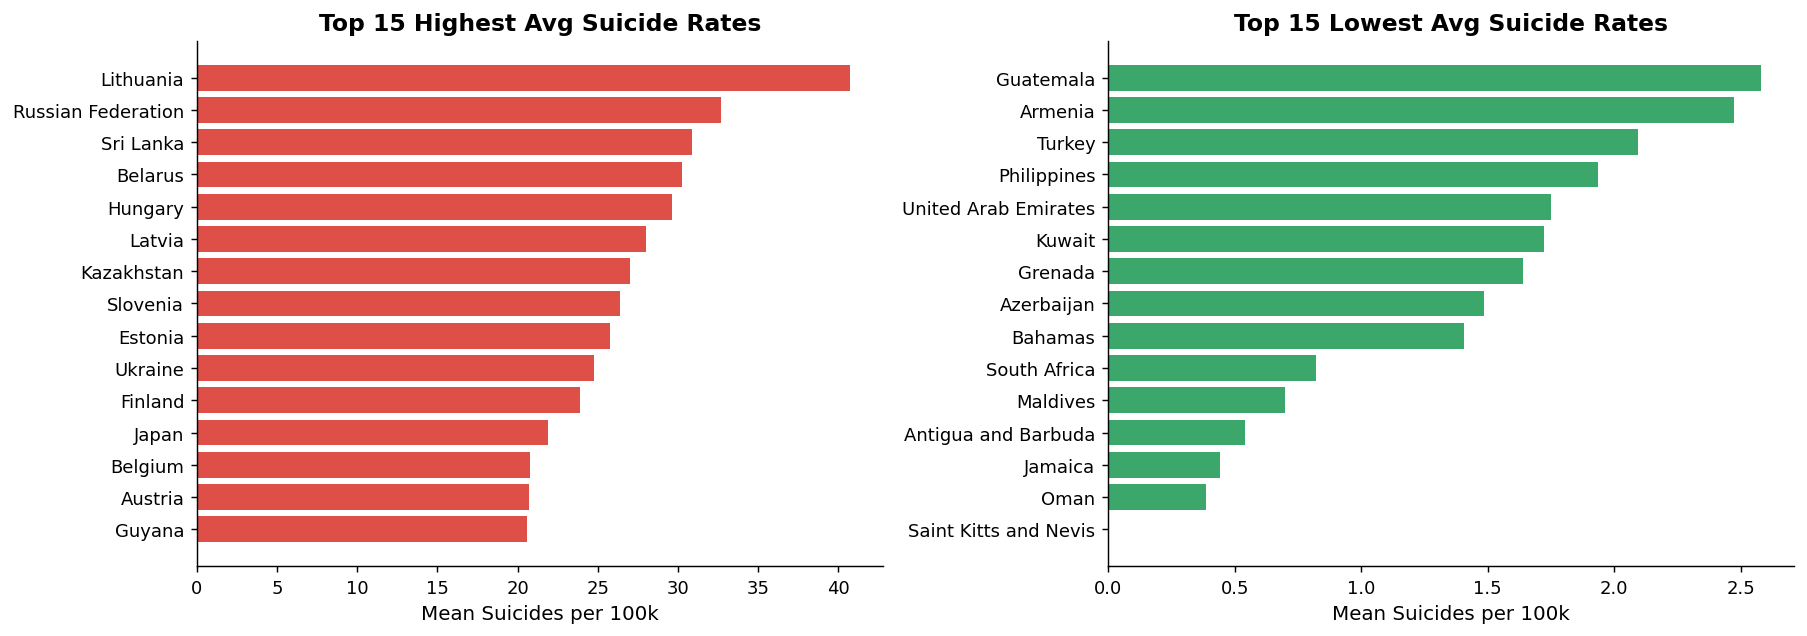

In [16]:
country_rates = (
    df.groupby(['country', 'year'])
      .agg(suicides=('suicides_no', 'sum'),
           population=('population', 'sum'))
      .assign(rate=lambda x: x['suicides'] / x['population'] * 100_000)
      .groupby('country')
      .agg(mean_rate=('rate', 'mean'), years=('rate', 'count'))
      .query('years >= 3')
      .reset_index()
      .sort_values('mean_rate', ascending=False)
)

TOP_N = 15
top    = country_rates.head(TOP_N)
bottom = country_rates.tail(TOP_N).sort_values('mean_rate')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top['country'][::-1], top['mean_rate'][::-1],
             color='#d73027', alpha=0.85)
axes[0].set(title=f'Top {TOP_N} Highest Avg Suicide Rates',
            xlabel='Mean Suicides per 100k')

axes[1].barh(bottom['country'], bottom['mean_rate'],
             color='#1a9850', alpha=0.85)
axes[1].set(title=f'Top {TOP_N} Lowest Avg Suicide Rates',
            xlabel='Mean Suicides per 100k')

plt.tight_layout()
plt.show()

## 7. GDP per Capita vs Suicide Rate
Do wealthier countries have higher or lower suicide rates?

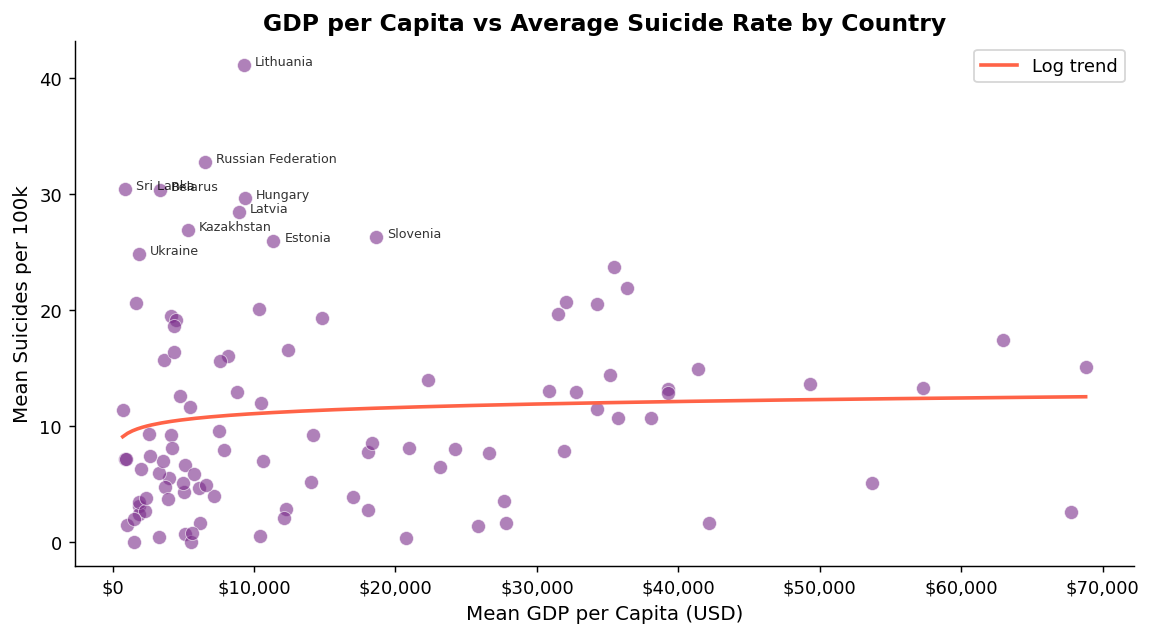

Pearson correlation (GDP per capita vs rate): 0.070


In [18]:
gdp_country = (
    df.groupby('country')
      .agg(suicides=('suicides_no', 'sum'),
           population=('population', 'sum'),
           gdp_per_capita=('gdp_per_capita', 'mean'))
      .assign(rate=lambda x: x['suicides'] / x['population'] * 100_000)
      .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(gdp_country['gdp_per_capita'], gdp_country['rate'],
           alpha=0.6, edgecolors='white', linewidth=0.5,
           color='#7b2d8b', s=60)

# ── Trend line ─────────────────────────────────────────────────────────────
m, b = np.polyfit(np.log1p(gdp_country['gdp_per_capita']), gdp_country['rate'], 1)
xs = np.linspace(gdp_country['gdp_per_capita'].min(),
                 gdp_country['gdp_per_capita'].max(), 200)
ax.plot(xs, m * np.log1p(xs) + b, color='tomato', linewidth=2, label='Log trend')

# ── Label notable outliers ─────────────────────────────────────────────────
threshold = gdp_country['rate'].quantile(0.90)
for _, row in gdp_country[gdp_country['rate'] > threshold].iterrows():
    ax.annotate(row['country'],
                xy=(row['gdp_per_capita'], row['rate']),
                xytext=(6, 0), textcoords='offset points',
                fontsize=7, alpha=0.8)

ax.set(title='GDP per Capita vs Average Suicide Rate by Country',
       xlabel='Mean GDP per Capita (USD)', ylabel='Mean Suicides per 100k')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

corr = gdp_country[['gdp_per_capita', 'rate']].corr().iloc[0, 1]
print(f"Pearson correlation (GDP per capita vs rate): {corr:.3f}")

## 8. Initial Modelling
We build three complementary models to understand what drives suicide rates:

1. **Multiple Linear Regression** – interpretable baseline with key predictors
2. **Random Forest** – captures non-linear interactions; feature importance
3. **Cross-validated performance comparison** – honest out-of-sample scores

> **Note:** the goal here is *insight*, not prediction. We use country-level
> aggregates so each row is independent — avoiding leakage from repeated
> country appearances in the raw panel.

In [20]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# ── Build country-level feature table ─────────────────────────────────────
country_model = (
    df.groupby('country')
      .agg(
          rate            = ('suicides_per_100k', 'mean'),
          gdp_per_capita  = ('gdp_per_capita',    'mean'),
          hdi             = ('hdi',               'mean'),
          population      = ('population',        'mean'),
          pct_male        = ('sex', lambda s: (s == 'male').mean()),
      )
      .dropna()
      .reset_index()
)

# Log-transform skewed predictors
country_model['log_gdp'] = np.log1p(country_model['gdp_per_capita'])
country_model['log_pop'] = np.log1p(country_model['population'])

FEATURES = ['log_gdp', 'log_pop', 'hdi', 'pct_male']
TARGET   = 'rate'

X = country_model[FEATURES].values
y = country_model[TARGET].values

print(f"Modelling dataset: {X.shape[0]} countries, {X.shape[1]} features")
country_model[FEATURES + [TARGET]].describe().round(2)

Modelling dataset: 90 countries, 4 features


,log_gdp,log_pop,hdi,pct_male,rate
count,90.00,90.00,90.00,90.0,90.00
mean,9.12,12.90,0.77,0.5,12.00
std,1.15,1.87,0.08,0.0,9.23
min,6.58,8.72,0.58,0.5,0.52
25%,8.31,12.01,0.71,0.5,4.64
50%,9.09,12.96,0.77,0.5,10.51
75%,10.22,14.03,0.84,0.5,18.13
max,11.14,16.89,0.92,0.5,40.42


### 8.1 Multiple Linear Regression
Fit a Ridge-regularised regression to understand the direction and
rough magnitude of each predictor's effect on the mean suicide rate.

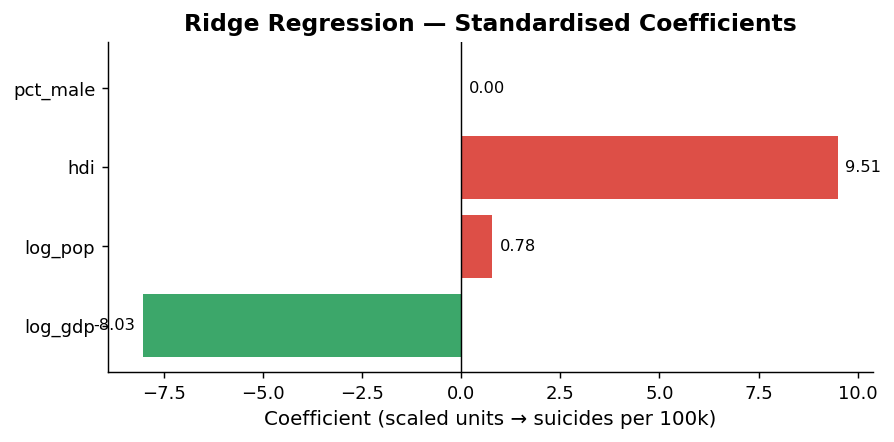

Ridge  5-fold CV  R²: 0.158 ± 0.100
Ridge  5-fold CV MAE: 6.72 ± 1.13


In [22]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=1.0))
])
lr_pipe.fit(X, y)

coefs = dict(zip(FEATURES, lr_pipe.named_steps['model'].coef_))

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ['#d73027' if v > 0 else '#1a9850' for v in coefs.values()]
bars = ax.barh(list(coefs.keys()), list(coefs.values()), color=colors, alpha=0.85)
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set(title='Ridge Regression — Standardised Coefficients',
       xlabel='Coefficient (scaled units → suicides per 100k)')
plt.tight_layout()
plt.show()

cv_r2  = cross_val_score(lr_pipe, X, y, cv=kf, scoring='r2')
cv_mae = cross_val_score(lr_pipe, X, y, cv=kf, scoring='neg_mean_absolute_error')
print(f"Ridge  5-fold CV  R²: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
print(f"Ridge  5-fold CV MAE: {(-cv_mae).mean():.2f} ± {(-cv_mae).std():.2f}")

### 8.2 Random Forest
A Random Forest handles non-linearities and interactions automatically.
We use permutation-based feature importances so they are on a comparable scale.

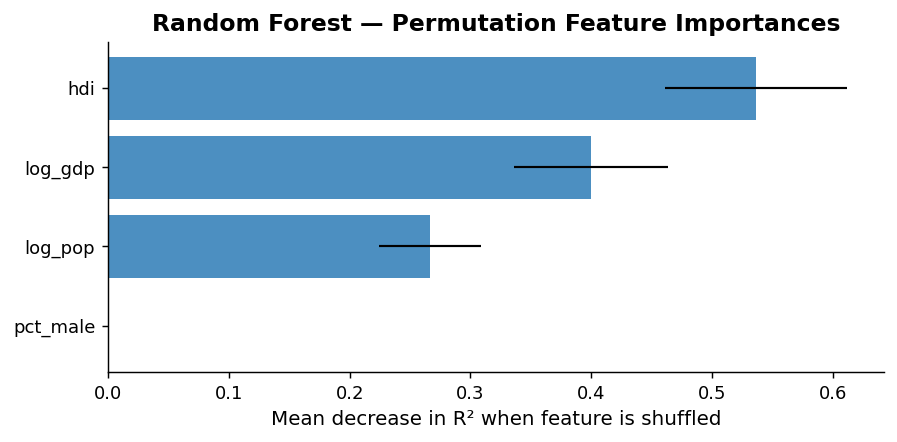

RF     5-fold CV  R²: 0.046 ± 0.175
RF     5-fold CV MAE: 6.81 ± 0.70


In [24]:
from sklearn.inspection import permutation_importance

rf = RandomForestRegressor(n_estimators=300, random_state=42,
                           max_features='sqrt', min_samples_leaf=3)
rf.fit(X, y)

# Permutation importance (more reliable than impurity-based)
perm = permutation_importance(rf, X, y, n_repeats=30, random_state=42)
imp_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': perm.importances_mean,
    'std':        perm.importances_std,
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(imp_df['feature'], imp_df['importance'],
        xerr=imp_df['std'], color='#2c7bb6', alpha=0.85,
        error_kw={'linewidth': 1.2})
ax.set(title='Random Forest — Permutation Feature Importances',
       xlabel='Mean decrease in R² when feature is shuffled')
plt.tight_layout()
plt.show()

cv_r2_rf  = cross_val_score(rf, X, y, cv=kf, scoring='r2')
cv_mae_rf = cross_val_score(rf, X, y, cv=kf, scoring='neg_mean_absolute_error')
print(f"RF     5-fold CV  R²: {cv_r2_rf.mean():.3f} ± {cv_r2_rf.std():.3f}")
print(f"RF     5-fold CV MAE: {(-cv_mae_rf).mean():.2f} ± {(-cv_mae_rf).std():.2f}")

### 8.3 Model Comparison & Residual Diagnostics
Compare all models side-by-side, then inspect the Ridge residuals to check
whether regression assumptions hold reasonably well.

                   CV R²  R² std  CV MAE
Model                                   
Ridge Regression   0.158   0.100   6.718
Random Forest      0.046   0.175   6.808
Gradient Boosting -0.061   0.241   6.938


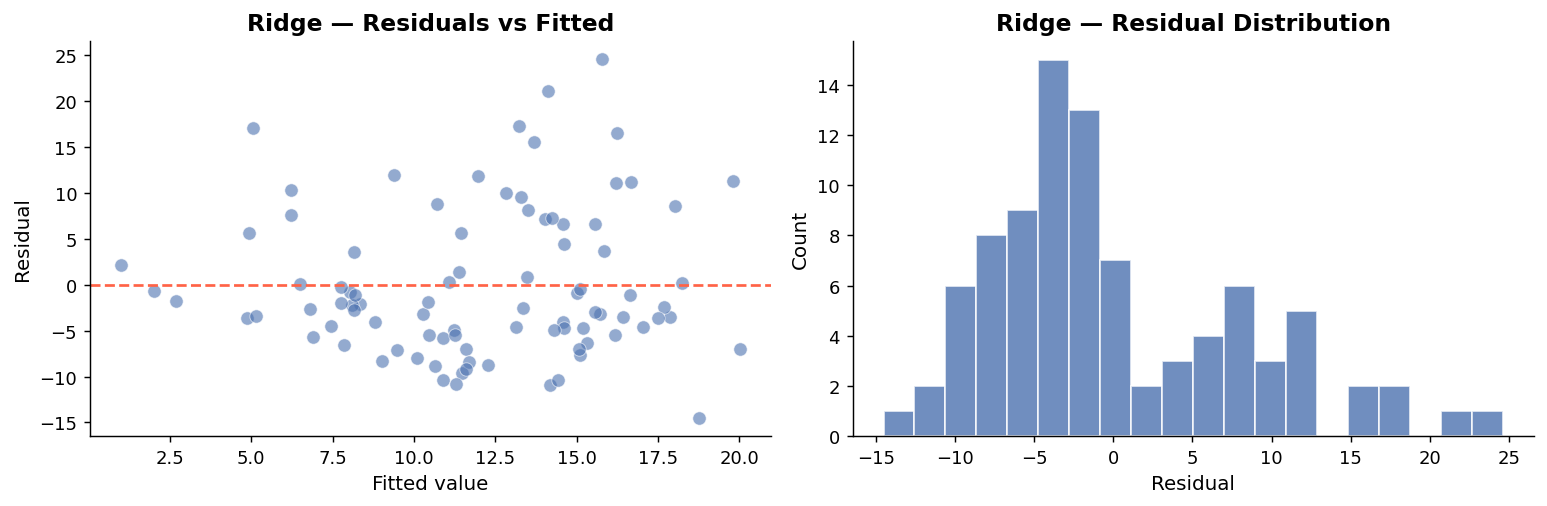


Largest positive residuals (rate much higher than model expects):
   country      rate  residual
 Lithuania 40.415573 24.630790
 Sri Lanka 35.295152 21.176375
Kazakhstan 30.511282 17.269568
    Guyana 22.186400 17.134264
   Hungary 32.761516 16.525784

Largest negative residuals (rate much lower than model expects):
            country     rate   residual
            Georgia 4.228712 -14.530784
            Armenia 3.275872 -10.918561
            Jamaica 0.521765 -10.757229
             Greece 4.064839 -10.364540
Antigua and Barbuda 0.552901 -10.339962


In [26]:
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                               max_depth=3, random_state=42)
cv_r2_gb  = cross_val_score(gb, X, y, cv=kf, scoring='r2')
cv_mae_gb = cross_val_score(gb, X, y, cv=kf, scoring='neg_mean_absolute_error')

results = pd.DataFrame({
    'Model': ['Ridge Regression', 'Random Forest', 'Gradient Boosting'],
    'CV R²':  [cv_r2.mean(),    cv_r2_rf.mean(),    cv_r2_gb.mean()],
    'R² std': [cv_r2.std(),     cv_r2_rf.std(),     cv_r2_gb.std()],
    'CV MAE': [(-cv_mae).mean(), (-cv_mae_rf).mean(), (-cv_mae_gb).mean()],
}).set_index('Model').round(3)

print(results.to_string())

# ── Residual plot (Ridge) ──────────────────────────────────────────────────
y_pred_lr = lr_pipe.predict(X)
residuals  = y - y_pred_lr

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_lr, residuals, alpha=0.6, color='#4C72B0',
                edgecolors='white', linewidth=0.5, s=55)
axes[0].axhline(0, color='tomato', linewidth=1.5, linestyle='--')
axes[0].set(title='Ridge — Residuals vs Fitted',
            xlabel='Fitted value', ylabel='Residual')

axes[1].hist(residuals, bins=20, color='#4C72B0', alpha=0.8, edgecolor='white')
axes[1].set(title='Ridge — Residual Distribution',
            xlabel='Residual', ylabel='Count')

plt.tight_layout()
plt.show()

# ── Highlight largest residuals ────────────────────────────────────────────
country_model['residual'] = residuals
print("\nLargest positive residuals (rate much higher than model expects):")
print(country_model.nlargest(5, 'residual')[['country', 'rate', 'residual']].to_string(index=False))
print("\nLargest negative residuals (rate much lower than model expects):")
print(country_model.nsmallest(5, 'residual')[['country', 'rate', 'residual']].to_string(index=False))

## 9. Extended Model Diagnostics

1. **Predicted vs Actual** – how well do model predictions track real values?
2. **Learning Curves** – are we overfitting or underfitting?
3. **SHAP Values** – which features drive individual predictions?

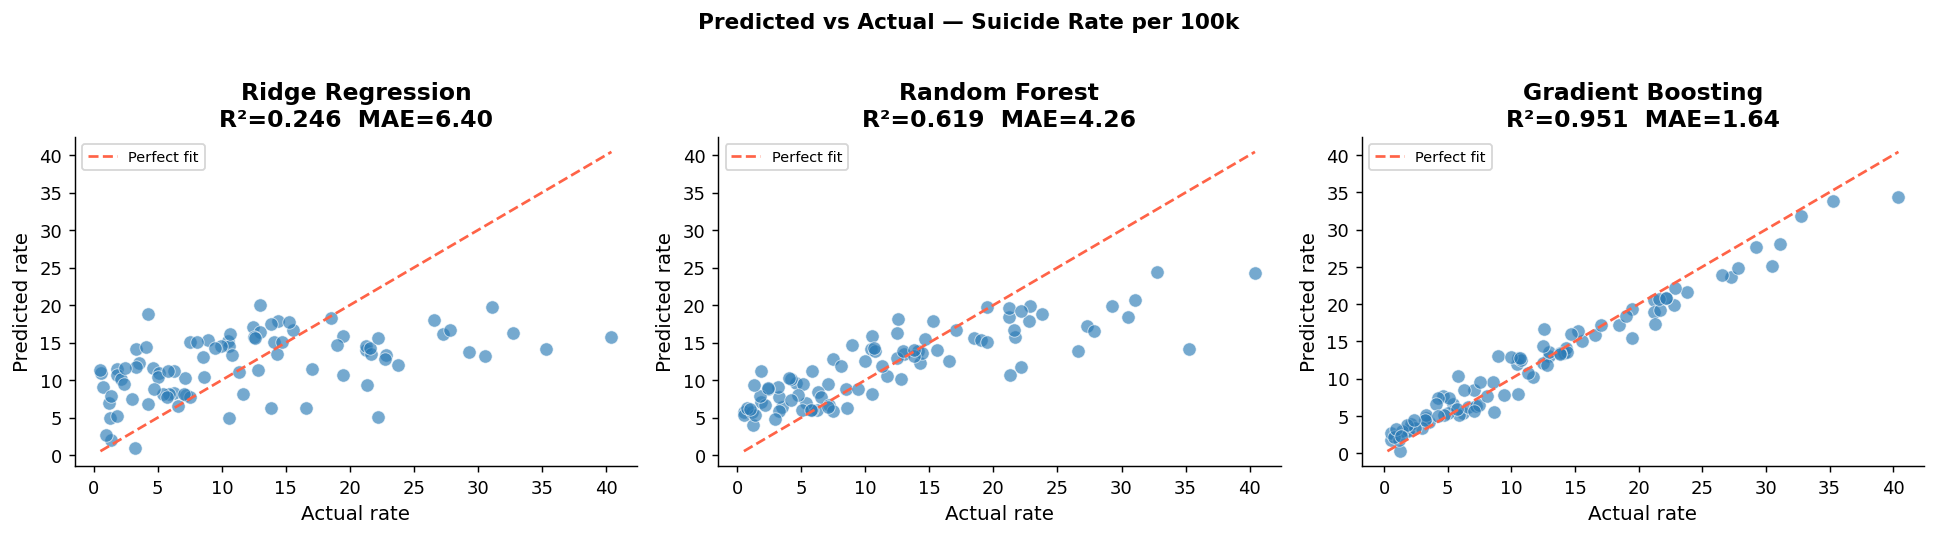

In [28]:
gb.fit(X, y)  # fit GB so we have all three trained

y_preds = {
    'Ridge Regression':    lr_pipe.predict(X),
    'Random Forest':       rf.predict(X),
    'Gradient Boosting':   gb.predict(X),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, y_pred) in zip(axes, y_preds.items()):
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    ax.scatter(y, y_pred, alpha=0.65, edgecolors='white',
               linewidth=0.5, color='#2c7bb6', s=55)
    lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
    ax.plot(lims, lims, color='tomato', linewidth=1.5, linestyle='--', label='Perfect fit')
    ax.set(title=f'{name}\nR²={r2:.3f}  MAE={mae:.2f}',
           xlabel='Actual rate', ylabel='Predicted rate')
    ax.legend(fontsize=8)

plt.suptitle('Predicted vs Actual — Suicide Rate per 100k', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

### 9.2 Learning Curves
A large gap between training and validation score = overfitting.
Curves converging at a low score = underfitting.

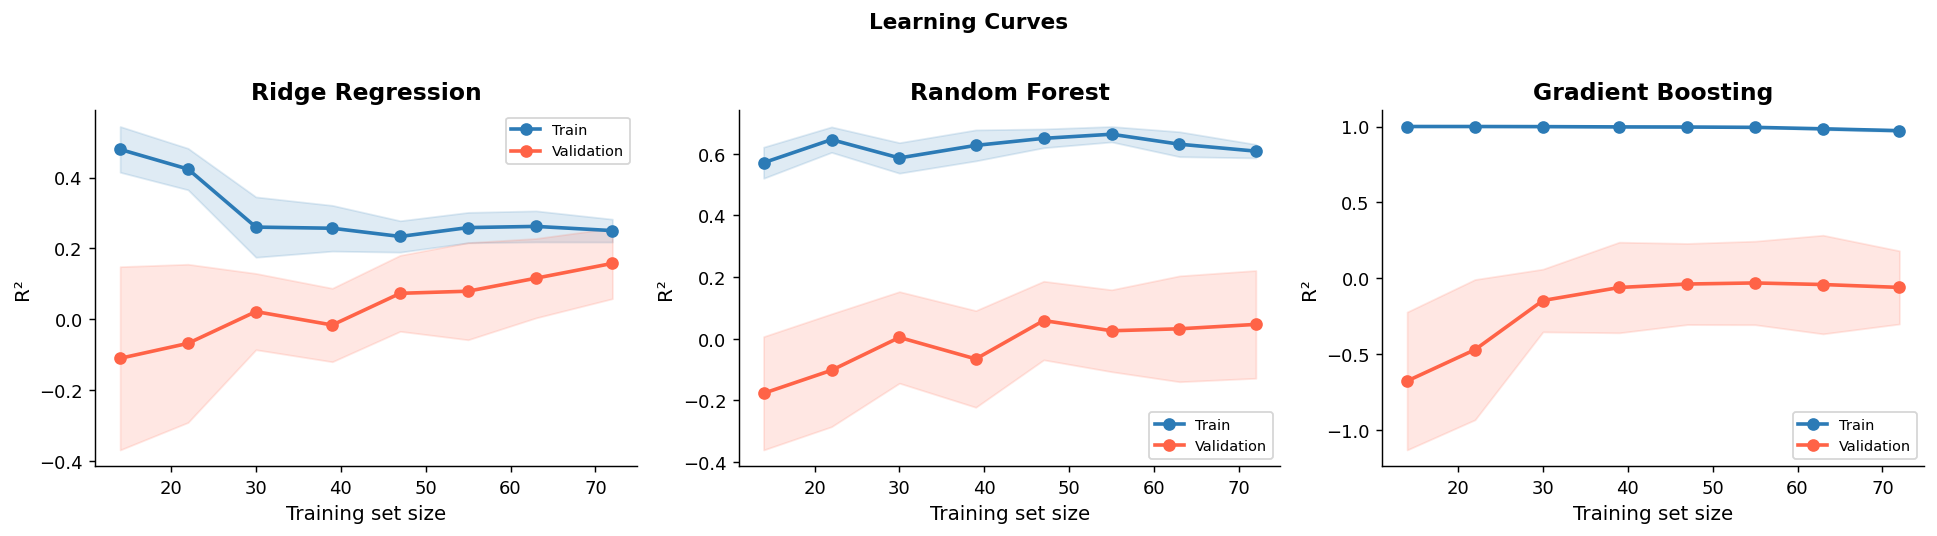

In [31]:
from sklearn.model_selection import learning_curve

models_lc = {
    'Ridge Regression':  lr_pipe,
    'Random Forest':     rf,
    'Gradient Boosting': gb,
}

train_sizes = np.linspace(0.2, 1.0, 8)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models_lc.items()):
    ts, train_scores, val_scores = learning_curve(
        model, X, y, cv=kf,
        train_sizes=train_sizes,
        scoring='r2'
    )
    ax.plot(ts, train_scores.mean(axis=1), 'o-', color='#2c7bb6',
            label='Train', linewidth=2)
    ax.fill_between(ts,
                    train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1),
                    alpha=0.15, color='#2c7bb6')
    ax.plot(ts, val_scores.mean(axis=1), 'o-', color='tomato',
            label='Validation', linewidth=2)
    ax.fill_between(ts,
                    val_scores.mean(axis=1) - val_scores.std(axis=1),
                    val_scores.mean(axis=1) + val_scores.std(axis=1),
                    alpha=0.15, color='tomato')
    ax.set(title=name, xlabel='Training set size', ylabel='R²')
    ax.legend(fontsize=8)

plt.suptitle('Learning Curves', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

### 9.3 SHAP Values
SHAP (SHapley Additive exPlanations) shows how much each feature
pushes an individual prediction above or below the baseline.
We use the Random Forest here as it tends to be the best performer.

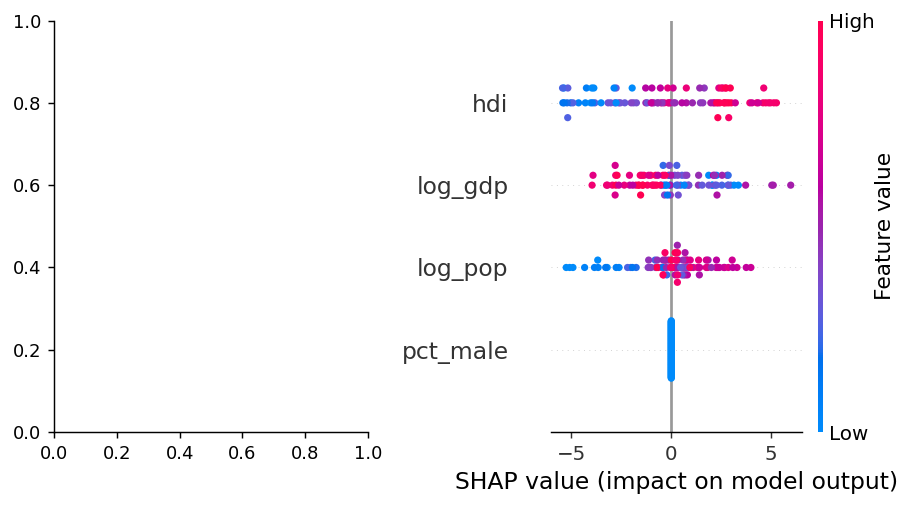

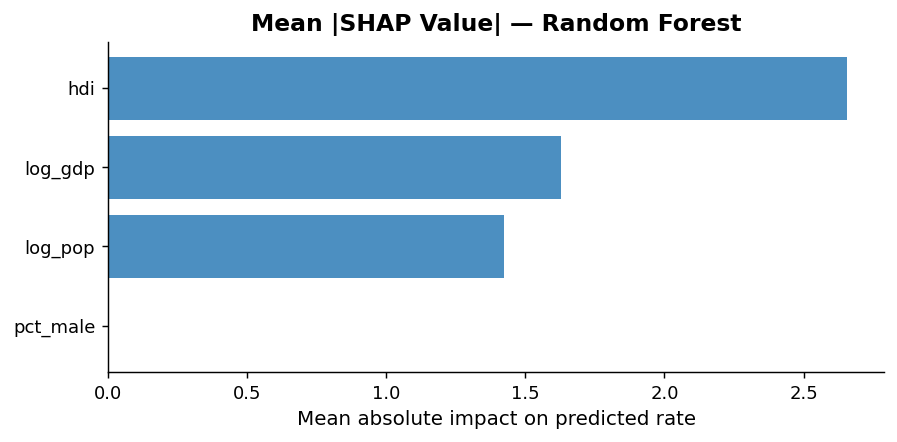


Mean |SHAP| per feature:
pct_male    0.000
log_pop     1.424
log_gdp     1.629
hdi         2.656


In [33]:
!pip install shap -q

import shap

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)
shap_df     = pd.DataFrame(shap_values, columns=FEATURES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Beeswarm-style summary (manual, no shap.plots to avoid display issues) ─
shap.summary_plot(shap_values, X, feature_names=FEATURES,
                  show=False, plot_size=None)
plt.gcf().set_size_inches(7, 4)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Mean absolute SHAP bar chart ───────────────────────────────────────────
mean_abs = shap_df.abs().mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(mean_abs.index, mean_abs.values, color='#2c7bb6', alpha=0.85)
ax.set(title='Mean |SHAP Value| — Random Forest',
       xlabel='Mean absolute impact on predicted rate')
plt.tight_layout()
plt.show()

print("\nMean |SHAP| per feature:")
print(mean_abs.round(3).to_string())